In [85]:
import pandas as pd
import numpy as np
import sys
import os
notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..'))
project_path = os.path.abspath(os.path.join(src_path, '..'))
sys.path.append(src_path)
sys.path.append(project_path)
from src.database import DatabaseManager
import pyarrow.parquet as pq
db = DatabaseManager()

In [86]:
draft_features = pd.read_parquet(f'{project_path}/data/training_set_v1.parquet')
draft_features['draft_diff'].describe()

count    204598.000000
mean          0.000064
std           0.055496
min          -0.348934
25%          -0.032577
50%          -0.000023
75%           0.032739
max           0.357425
Name: draft_diff, dtype: float64

In [87]:
query_matches = '''
    SELECT id as match_id, "gameVersionId", "didRadiantWin", 
           radiant_draft_score, dire_draft_score 
    FROM match_details
'''
matches = db.select_to_df(query_matches)

query_ratings = '''
    WITH team_stats AS (
        SELECT 
            match_id,
            is_radiant,
            AVG(mu) as avg_mu,
            STDDEV(mu) as std_mu,
            MAX(mu) as max_mu,
            SUM(sigma) as total_sigma
        FROM rating_history
        GROUP BY match_id, is_radiant
    )
    SELECT 
        r.match_id,
        r.avg_mu as radiant_avg_mu, 
        r.std_mu as radiant_std_mu, 
        r.max_mu as radiant_max_mu, 
        r.total_sigma as radiant_total_sigma,
        d.avg_mu as dire_avg_mu, 
        d.std_mu as dire_std_mu, 
        d.max_mu as dire_max_mu, 
        d.total_sigma as dire_total_sigma
    FROM team_stats r
    JOIN team_stats d ON r.match_id = d.match_id
    WHERE r.is_radiant = true AND d.is_radiant = false;
'''
ratings = db.select_to_df(query_ratings)

df = pd.merge(matches, ratings, on='match_id', how='inner')

df_full = df.dropna(subset=[
    'radiant_avg_mu', 'dire_avg_mu', 
    'radiant_draft_score', 'dire_draft_score', 
    'gameVersionId'
]).copy()

df_full.fillna(0, inplace=True)
df_full = pd.merge(
    df_full,
    draft_features,
    on='match_id'
)
df_full['mu_diff'] = df_full['radiant_avg_mu'] - df_full['dire_avg_mu']
df_full['std_diff'] = df_full['radiant_std_mu'] - df_full['dire_std_mu']
df_full['max_mu_diff'] = df_full['radiant_max_mu'] - df_full['dire_max_mu']
df_full['sigma_total_diff'] = df_full['radiant_total_sigma'] - df_full['dire_total_sigma']

In [88]:
df_full[df_full['gameVersionId'] > 72].sort_values(by='gameVersionId', ascending=True)

,match_id,gameVersionId,didRadiantWin,radiant_draft_score,dire_draft_score,radiant_avg_mu,radiant_std_mu,radiant_max_mu,radiant_total_sigma,dire_avg_mu,dire_std_mu,dire_max_mu,dire_total_sigma,draft_diff,label,mu_diff,std_diff,max_mu_diff,sigma_total_diff
33115,3097382042,73,False,0.456207,0.493300,29.135525,5.360293,36.391554,36.712372,31.292604,3.916267,34.699307,37.792693,0.004343,0,-2.157080,1.444026,1.692246,-1.080321
33114,3097374718,73,False,0.472488,0.519217,35.764353,5.528003,39.450996,25.927091,33.090024,3.368912,37.547499,26.865986,0.103638,0,2.674329,2.159091,1.903498,-0.938895
33184,3103119663,73,False,0.451164,0.544618,27.469323,2.021007,29.802817,26.854306,27.753890,4.592921,33.831278,34.838105,-0.058503,0,-0.284567,-2.571914,-4.028461,-7.983799
33183,3103117092,73,True,0.535369,0.479818,31.881084,5.942750,38.548133,27.158730,30.391017,6.459691,38.106325,27.826259,-0.024244,1,1.490067,-0.516941,0.441808,-0.667529
33182,3103015115,73,False,0.469477,0.507580,28.344833,2.014905,30.674254,26.863283,26.252311,4.611236,32.389609,35.121674,0.124058,0,2.092522,-2.596332,-1.715356,-8.258391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5132,8743561222,183,True,0.558213,0.554348,51.024440,6.197400,55.917591,24.061721,43.000508,4.995911,50.333706,23.833637,0.020003,1,8.023931,1.201489,5.583885,0.228084
5116,8743362379,183,False,0.518297,0.529000,25.949143,0.177177,26.028379,22.297972,26.584203,0.622906,27.448535,22.393548,0.044504,0,-0.635060,-0.445729,-1.420157,-0.095576
5117,8743378574,183,False,0.549529,0.546392,21.636860,4.270293,27.698647,25.710721,24.889816,3.948533,30.046274,27.562351,0.024721,0,-3.252956,0.321760,-2.347627,-1.851630
5118,8743423405,183,False,0.522886,0.518307,27.176068,0.622906,28.040400,22.375761,25.362257,0.177177,25.441493,22.283413,0.005369,0,1.813811,0.445729,2.598907,0.092348


In [89]:
df_train = df_full[(df_full['gameVersionId'] <= 178) & (df_full['gameVersionId'] > 72)].copy()
df_test = df_full[(df_full['gameVersionId'] > 178) & (df_full['gameVersionId'] > 72)].copy()
features = ['mu_diff', 'std_diff', 'max_mu_diff', 'sigma_total_diff', 'draft_diff']
X_train = df_train[features].values
X_test = df_test[features].values
y_train = df_train['didRadiantWin'].astype('int').values
y_test = df_test['didRadiantWin'].astype('int').values

In [90]:
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
log_reg_pipeline = Pipeline([
    ('pt', PowerTransformer()),
    ('model', LogisticRegression(max_iter=1000, solver='saga'))
])

In [91]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-validation accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

Cross-validation accuracies: [0.61356729 0.61626195 0.61071596 0.60958797 0.61770327]
Mean CV Accuracy: 0.6136 (± 0.0031)


         Feature  Coefficient
         mu_diff     0.500723
sigma_total_diff    -0.238803
      draft_diff     0.133699
        std_diff     0.032256
     max_mu_diff     0.027161
Test set accuracy: 0.5878214184797965
              precision    recall  f1-score   support

           0       0.57      0.55      0.56     16897
           1       0.60      0.62      0.61     18493

    accuracy                           0.59     35390
   macro avg       0.59      0.59      0.59     35390
weighted avg       0.59      0.59      0.59     35390



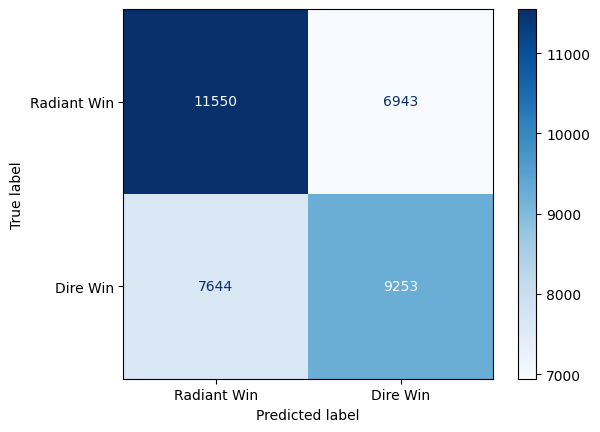

In [92]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
log_reg_pipeline.fit(X_train, y_train)
y_pred = log_reg_pipeline.predict(X_test)

coefs = log_reg_pipeline.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Abs_Magnitude': np.abs(coefs)
})

coef_df = coef_df.sort_values(by='Abs_Magnitude', ascending=False).drop(columns=['Abs_Magnitude'])
print(coef_df.to_string(index=False))
print(f'Test set accuracy: {accuracy_score(y_test, y_pred)}')
print(f'{classification_report(y_test, y_pred)}')
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Radiant Win', 'Dire Win'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [93]:
import joblib
joblib.dump(log_reg_pipeline, f'{project_path}/src/ml_models/log_reg_model.joblib')

['c:\\Users\\benib\\Projects\\Dota/src/ml_models/log_reg_model.joblib']